In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("https://github.com/andvise/DataAnalyticsDatasets/blob/dc74027bd063510ede437e4d612f41eb078e49b9/titanic.csv?raw=true")

The goal is to predict if the passenger survived or not. Your task is to decide if the first branch of the decision tree should use the **Sex** or the **Pclass** attribute and why.

### Entropy function
The first step is to create a function that computes the entropy of a dataframe for a given attribute(column).

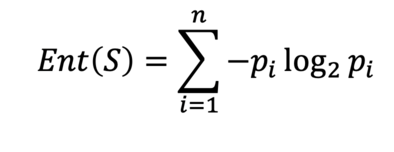

In [5]:
import math

def entropy(df, column):
    entropy = 0
    freqs = df[column].value_counts() / len(df[column])
    for freq in freqs:
        entropy += -freq * math.log2(freq)
    return entropy

In [6]:
entropy(df, "Survived") # it should be 0.9618806789594468

0.9618806789594467

In [8]:
df_male = df[df["Sex"] == "male"]
entropy(df_male, "Survived") # it should be 0.7019458258949879

0.7019458258949879

In [7]:
def gain(df, col):
  total_entropy = entropy(df, "Survived")
  col_freqs = df[col].value_counts()/len(df[col])
  vals = df[col].unique()
  gain = total_entropy
  for val in vals:
    gain = gain - col_freqs[val]*entropy(df[df[col] == val], "Survived")
  return gain

In [ ]:
gain(df, "Sex")

np.float64(0.21684950483126514)

In [ ]:
gain(df, "Pclass")

np.float64(0.08286373372692335)